In [54]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [55]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [56]:
# 아래 두 단계는 쓰레기값(0값)들을 연산에서 제거해 mse를 줄이기 위함
# 0이 불가능한 컬럼만 선택
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 0 → NaN 변환
df[cols] = df[cols].replace(0, np.nan)

# 결측치 확인
print(df[cols].isnull().sum())

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [57]:
#NaN 값들을 정상 진단(Outcome=0)과 당뇨(Outcome=1) 그룹별 중앙값으로 대체
for col in cols:
    df.loc[(df[col].isnull()) & (df['Outcome'] == 0), col] = \
        df.loc[df['Outcome'] == 0, col].median()
    df.loc[(df[col].isnull()) & (df['Outcome'] == 1), col] = \
        df.loc[df['Outcome'] == 1, col].median()

In [58]:
df = df.drop('Outcome', axis=1)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33


In [59]:
X = df.drop('BMI', axis=1)
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,169.5,0.627,50
1,1,85.0,66.0,29.0,102.5,0.351,31
2,8,183.0,64.0,32.0,169.5,0.672,32
3,1,89.0,66.0,23.0,94.0,0.167,21
4,0,137.0,40.0,35.0,168.0,2.288,33


In [60]:
y=df['BMI']
y.head()

,BMI
0,33.6
1,26.6
2,23.3
3,28.1
4,43.1


In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)



(614, 7)
(154, 7)


In [62]:
#LinearRegression

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


model = LinearRegression()
model.fit(X_train, y_train)
ly_preds = model.predict(X_test)

print('평균제곱오차', mean_squared_error(ly_preds, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(ly_preds, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(ly_preds, y_test))

평균제곱오차 33.50384923105064
평균제곱오차 33.50384923105064
평균제곱오차 33.503849231050644


Text(0, 0.5, 'Predicted')

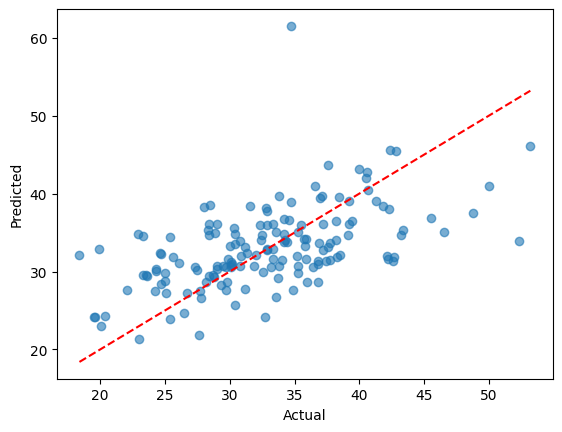

In [63]:
#LinearRegression 모델 실제값, 예측값 산점도
plt.scatter(y_test, ly_preds, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')  # 완벽한 예측선
plt.xlabel("Actual")
plt.ylabel("Predicted")

In [64]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error

dy_preds = model.predict(X_test)
print('평균제곱오차', mean_squared_error(dy_preds, y_test))

평균제곱오차 84.10681818181818


Text(0, 0.5, 'Predicted')

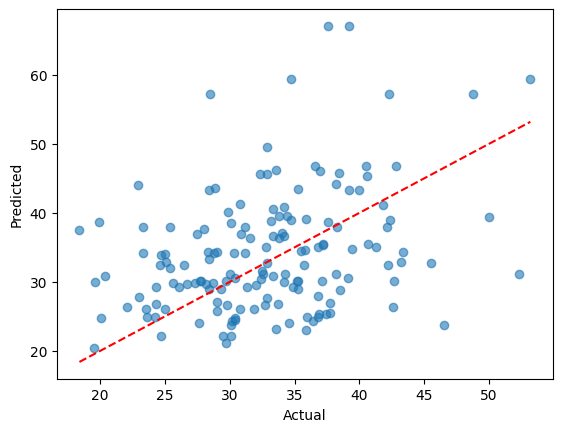

In [65]:
#DecisionTreeRegressor 모델 실제값, 예측값 산점도
#대각선과 가까울 수록 좋은 모델
plt.scatter(y_test, dy_preds, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')  # 완벽한 예측선
plt.xlabel("Actual")
plt.ylabel("Predicted")

In [66]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error

ry_preds = model.predict(X_test)
print('평균제곱오차', mean_squared_error(ry_preds, y_test))

평균제곱오차 33.19082509090911


Text(0, 0.5, 'Predicted')

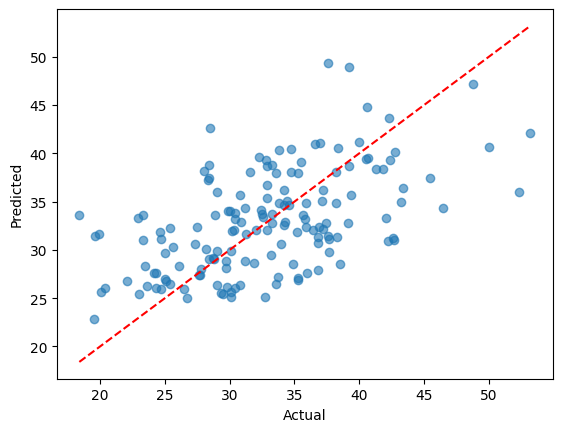

In [67]:
#RandomForestRegressor 모델 실제값, 예측값 산점도
plt.scatter(y_test, ry_preds, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')  # 완벽한 예측선
plt.xlabel("Actual")
plt.ylabel("Predicted")

In [68]:
#번외

from sklearn.svm import SVR

model = SVR(kernel='linear')
model.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error
sy_preds = model.predict(X_test)
print('평균제곱오차', mean_squared_error(sy_preds, y_test))

평균제곱오차 33.04162639698872


Text(0, 0.5, 'Predicted')

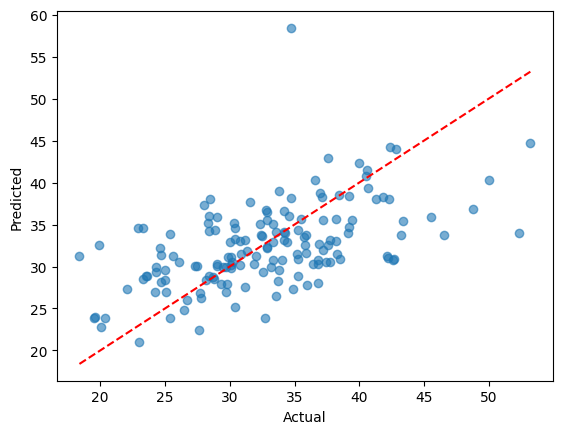

In [69]:
plt.scatter(y_test, sy_preds, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')  # 완벽한 예측선
plt.xlabel("Actual")
plt.ylabel("Predicted")